In [5]:
# ==========================================================
# Project Setup
# ==========================================================

import sys
from pathlib import Path


# 获取项目根目录
PROJECT_ROOT = Path("..").resolve()


# 加入 Python 模块搜索路径
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


print("Project root:", PROJECT_ROOT)

Project root: D:\desktop\work-projects\breast-ultrasound-segmentation


In [10]:
from src.dataset import BUSIDataset
from torch.utils.data import DataLoader

#=============================================
#创建训练Dataset
#=============================================
train_dataset = BUSIDataset(
    csv_file="../data/splits/train.csv",
    image_size=(256, 256)
)

#=============================================
#创建DataLoader
#=============================================
train_loader = DataLoader(
    train_dataset,
    batch_size = 8,

    #训练集顺序需要打乱
    shuffle = True,
    # Windows + Jupyter 暂时设为 0 最稳
    num_workers=0
)
#从dataloder拿一个batch
batch = next(
    iter(train_loader)  #创建一个dataloader迭代器，准备一批一批的往外拿数据
)
print(batch.keys())

Loaded dataset: 452 images
dict_keys(['image', 'mask', 'image_path', 'num_masks'])


In [12]:
images = batch["image"]

masks = batch["mask"]
print(
    "Images shape:",
    images.shape
)

print(
    "Masks shape:",
    masks.shape
)

Images shape: torch.Size([8, 1, 256, 256])
Masks shape: torch.Size([8, 1, 256, 256])


### 使用真实的数据接通unet基础模型

In [15]:
import torch
from src.model import UNet

model = UNet()

model.eval()  #将模型切换到验证/推理模式（不再是训练模式，因为我们目前只是测试前向传播，所以不train，只是验证推理
with torch.no_grad():  #表示这段代码只是做测试不需要记录梯度，with表示在某个特殊环境下执行某段代码
    logits = model(images)
print(
    "Logits shape:",
    logits.shape
)
#模型此时输出的并不是0/1，而是任意实数，或者叫做原始分数
print(
    "Logits min:",
    logits.min().item()
)

print(
    "Logits max:",
    logits.max().item()
)
#将原始分数转换为概率值
#sigmoid将任意实数压缩到0-1
probs = torch.sigmoid(
    logits
)
print(
    "Probability min:",
    probs.min().item()
)

print(
    "Probability max:",
    probs.max().item()
)

Logits shape: torch.Size([8, 1, 256, 256])
Logits min: 0.06232515349984169
Logits max: 0.07336137443780899
Probability min: 0.5155762434005737
Probability max: 0.5183321237564087


In [ ]:
# 设置一个阈值，将最后的预测输出变成0/1，以便于对应mask
#目前觉得这个阈值很抓马
pred_masks = (
    probs > 0.5
).float()
print(
    "Prediction shape:",
    pred_masks.shape
)

print(
    "Prediction unique values:",
    torch.unique(pred_masks)
)

Prediction shape: torch.Size([8, 1, 256, 256])
Prediction unique values: tensor([0.])


### 梳理整个逻辑
             U-Net
               │
               ↓
            Logits
     任意实数，例如：
      -2.1  0.7  3.4
               │
               ↓
          torch.sigmoid
               │
               ↓
         Probability
             0~1
       0.11 0.67 0.97
               │
               ↓
        threshold = 0.5
               │
               ↓
        Prediction Mask
             0 / 1
               │
               ↓
       和 Ground Truth 比较

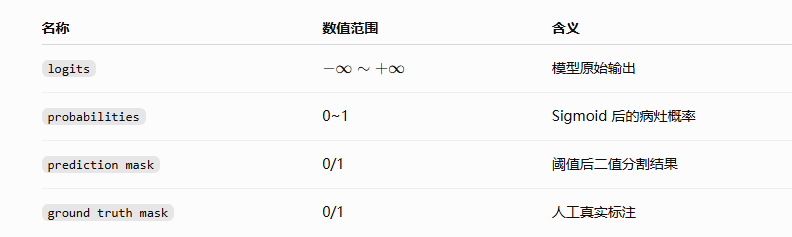

### 可视化一张还没有训练的预测

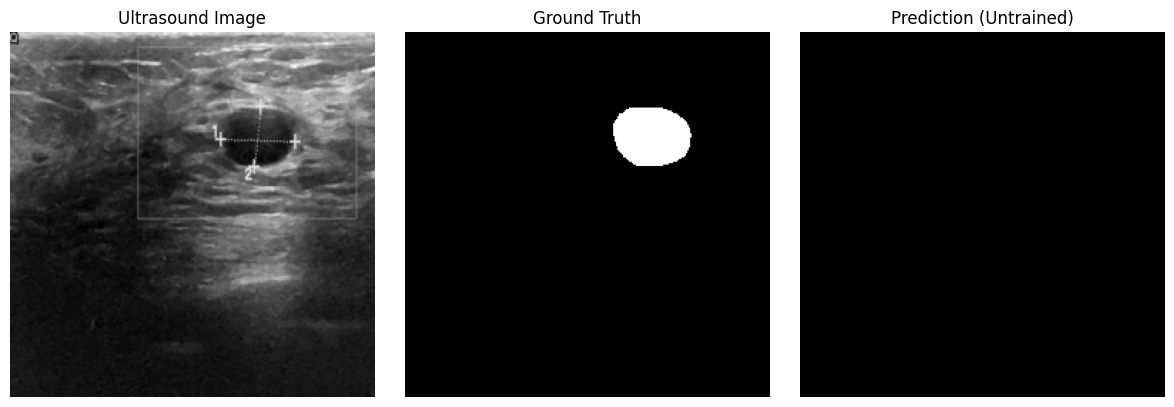

In [20]:
import matplotlib.pyplot as plt


# ============================================
# 取 batch 中第 1 张图
# ============================================

image = images[0]
true_mask = masks[0]
pred_mask = pred_masks[0]


# ============================================
# 去掉 channel 维度
#
# [1,256,256]
#        ↓
# [256,256]
# ============================================

image_np = image.squeeze(0).numpy()

true_mask_np = true_mask.squeeze(0).numpy()

pred_mask_np = pred_mask.squeeze(0).numpy()


# ============================================
# 可视化
# ============================================

plt.figure(
    figsize=(12, 4)
)


# 原始 BUSI 图像
plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    image_np,
    cmap="gray"
)

plt.title(
    "Ultrasound Image"
)

plt.axis("off")


# Ground Truth
plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    true_mask_np,
    cmap="gray"
)

plt.title(
    "Ground Truth"
)

plt.axis("off")


# 模型预测
plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    pred_mask_np,
    cmap="gray"
)

plt.title(
    "Prediction (Untrained)"
)

plt.axis("off")


plt.tight_layout()

plt.show()

In [21]:
print(
    "Image:",
    images.shape
)

print(
    "Ground Truth:",
    masks.shape
)

print(
    "Model Output:",
    logits.shape
)

Image: torch.Size([8, 1, 256, 256])
Ground Truth: torch.Size([8, 1, 256, 256])
Model Output: torch.Size([8, 1, 256, 256])


### 测试loss

In [ ]:
from src.loss import DiceBCELoss

#criterion是深度学习中一个非常常见的变量名，表示损失函数（loss function）
criterion = DiceBCELoss()
model.eval()
with torch.no_grad():
    logits = model(images)
    loss = criterion(
        logits,
        masks
    )
    print("Loss:",loss.item())  #因为模型还没训练，这个输出的loss值只是随机初始化模型在当前batch上的错误程度

Loss: 1.6112576723098755


### loss已经告诉模型错的多严重，optimizer就是告诉模型需要怎么修改参数---使用最经典的、最常见的Adam

In [ ]:
"""
完整的一个batch的训练流程
"""
import torch.optim as optim
from src.loss import DiceBCELoss

#=======================================
#1.创建loss
#=======================================
criterion = DiceBCELoss()

#=======================================
#2.创建optimizer
#=======================================
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

#3.切换到训练模式
model.train()

#4.清空上一轮梯度
optimizer.zero_grad()

#5.前向传播
logits = model(images)

#6.计算loss
loss = criterion(logits,masks)

#7.反向传播-----计算每个参数的梯度
loss.backward()  #torch.Tensor.backward()这是自带的方法

#8.更新参数
optimizer.step()

print("training loss:",loss.item())






training loss: 1.701453685760498


In [24]:
# ==========================================
# 设置训练 Epoch 数
# ==========================================

num_epochs = 5


for epoch in range(num_epochs):

    # --------------------------------------
    # 切换到训练模式
    # --------------------------------------

    model.train()


    # 用于累计整个 Epoch 的 Loss
    running_loss = 0.0


    # ======================================
    # 遍历所有 Batch
    # ======================================

    for batch in train_loader:

        # ----------------------------------
        # 取出 image 和 mask
        # ----------------------------------

        images = batch["image"]

        masks = batch["mask"]


        # ----------------------------------
        # 清空梯度
        # ----------------------------------

        optimizer.zero_grad()


        # ----------------------------------
        # Forward
        # ----------------------------------

        logits = model(
            images
        )


        # ----------------------------------
        # 计算 Loss
        # ----------------------------------

        loss = criterion(
            logits,
            masks
        )


        # ----------------------------------
        # Backward
        # ----------------------------------

        loss.backward()


        # ----------------------------------
        # 更新参数
        # ----------------------------------

        optimizer.step()


        # ----------------------------------
        # 累计 Loss
        # ----------------------------------

        running_loss += (
            loss.item()
        )


    # ======================================
    # 计算整个 Epoch 的平均 Loss
    # ======================================

    epoch_loss = (
        running_loss
        /
        len(train_loader)
    )

#f-string把变量直接塞进字符串打印出来
    print(
        f"Epoch "
        f"{epoch + 1}/{num_epochs} "
        f"- Train Loss: "
        f"{epoch_loss:.4f}"
    )

#cpu训练图像真是非常的慢啊！

Epoch 1/5 - Train Loss: 1.3405


KeyboardInterrupt: 